In [2]:
import scipy.io
import io
 
from data_loader import DataLoader

import numpy as np
from utils import *
from matplotlib import pyplot as plt
import numpy.random as rng
import pandas as pd

import os

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [4]:
home_dir = os.path.abspath(os.path.curdir)
data_dir = os.path.join(home_dir, '..', 'Data')
ultralight = os.path.join(data_dir, 'GG-Dataset-Tulio-Ultralight')

print(os.path.abspath(home_dir))
print(os.path.abspath(data_dir))
print(os.path.abspath(ultralight))

/Users/laravlasblom/Documents/Radboud/Thesis/Code/URI-project
/Users/laravlasblom/Documents/Radboud/Thesis/Code/Data
/Users/laravlasblom/Documents/Radboud/Thesis/Code/Data/GG-Dataset-Tulio-Ultralight


In [5]:
rats = ['Rat08', 'Rat09', 'Rat10', 'Rat11']

def load_data(rats):
    return DataLoader(ultralight, 'Hpc', rats=[rats])

In [6]:
%run functions_to_use.ipynb

In [5]:
rat_id = 0
rat = rats[rat_id]
data = load_data(rat)
spks = data.get_spk()
pos = data._get_pos()

sessions_spks = list(spks[rat].keys()) 
sessions_data = list(data.events[rat].keys())
sessions = np.intersect1d(sessions_spks, sessions_data)

spike_freq_per_sess = []

for i, s in enumerate(sessions):
    x, y, time = position_vars(s)
    total_time = int(np.array(time)[-1]) / 1000 # in sec
    neuron_spikes = spks[rat][s]['all']
    spike_counts_dict = {neuron_id: len(spike_times) for neuron_id, spike_times in neuron_spikes.items()}
    spike_counts = list(spike_counts_dict.values())
    spike_freq = [x / total_time for x in spike_counts]
    spike_freq_per_sess.append(spike_freq)

rat_id = 2
rat = rats[rat_id]
data = load_data(rat)
spks = data.get_spk()
pos = data._get_pos()

sessions_spks = list(spks[rat].keys()) 
sessions_data = list(data.events[rat].keys())
sessions = np.intersect1d(sessions_spks, sessions_data)

for i, s in enumerate(sessions):
    if i == 11:
        continue
    x, y, time = position_vars(s)
    total_time = int(np.array(time)[-1]) / 1000 # in sec
    neuron_spikes = spks[rat][s]['all']
    spike_counts_dict = {neuron_id: len(spike_times) for neuron_id, spike_times in neuron_spikes.items()}
    spike_counts = list(spike_counts_dict.values())
    spike_freq = [x / total_time for x in spike_counts]
    spike_freq_per_sess.append(spike_freq)

rat_id = 3
rat = rats[rat_id]
data = load_data(rat)
spks = data.get_spk()
pos = data._get_pos()

sessions_spks = list(spks[rat].keys()) 
sessions_data = list(data.events[rat].keys())
sessions = np.intersect1d(sessions_spks, sessions_data)

for i, s in enumerate(sessions):
    if i == 4:
        continue
    x, y, time = position_vars(s)
    total_time = int(np.array(time)[-1]) / 1000 # in sec
    neuron_spikes = spks[rat][s]['all']
    spike_counts_dict = {neuron_id: len(spike_times) for neuron_id, spike_times in neuron_spikes.items()}
    spike_counts = list(spike_counts_dict.values())
    spike_freq = [x / total_time for x in spike_counts]
    spike_freq_per_sess.append(spike_freq)

/Users/laravlasblom/Documents/Radboud/Thesis/Code/URI-project/data_loader.py:402: UserWarning: The file does not exist in the dataset, check the folder 
 /Users/laravlasblom/Documents/Radboud/Thesis/Code/Data/GG-Dataset-Tulio-Ultralight/Rat08/Rat08-20130722/States.mat
  self.__warning_msg(self.paths[rat][session]['States'])
/Users/laravlasblom/Documents/Radboud/Thesis/Code/URI-project/data_loader.py:592: UserWarning: The file does not exist in the dataset, check the folder 
 /Users/laravlasblom/Documents/Radboud/Thesis/Code/Data/GG-Dataset-Tulio-Ultralight/Rat08/Rat08-20130722/Rat08-20130722.rip.evt
  self.__warning_msg(path)
/Users/laravlasblom/Documents/Radboud/Thesis/Code/URI-project/data_loader.py:592: UserWarning: The file does not exist in the dataset, check the folder 
 /Users/laravlasblom/Documents/Radboud/Thesis/Code/Data/GG-Dataset-Tulio-Ultralight/Rat08/Rat08-20130718/Rat08-20130718.rip.evt
  self.__warning_msg(path)
/Users/laravlasblom/Documents/Radboud/Thesis/Code/URI-proj

In [6]:
def flatten(xss):
    return [x for xs in xss for x in xs]

all_spk_frequency = flatten(spike_freq_per_sess)

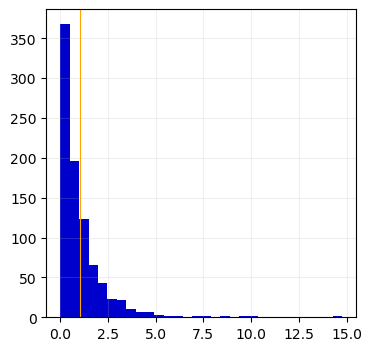

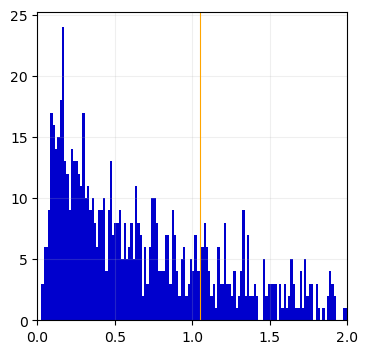

1.0502291248184106


In [7]:
plt.figure(figsize=(4,4))
plt.hist((all_spk_frequency), bins=30, color='mediumblue')
plt.axvline(np.mean(all_spk_frequency), color='orange', linewidth=0.8)
# plt.xticks(np.arange(0,25,5))
# plt.xlabel('Firing rate (Hz)')
# plt.ylabel('Occurrence')
plt.grid(True, alpha=0.2)
# plt.savefig('firingrate.svg')
plt.show()

plt.figure(figsize=(4,4))
plt.hist((all_spk_frequency), bins=1000, color='mediumblue')
plt.axvline(np.mean(all_spk_frequency), color='orange', linewidth=0.8)
# plt.xticks(np.arange(0,2,0.05))
# plt.xlabel('Firing rate (Hz)')
# plt.ylabel('Occurrence')
plt.grid(True, alpha=0.2)
plt.xlim(0, 2)
# plt.savefig('firingrate_zoom.svg')
plt.show()
print(np.mean(all_spk_frequency))

In [8]:
# plan: 
# idx = round(spk_time * srate_x)
# position_x[idx]
# np.histogram(position_x[idx])
# position_spk_count = np.histogram(position_x[idx])
# position_occupancy = np.histogram(position_x)
# position_firing_rate = position_spk_count/position_occupancy

In [7]:
rat_id = 3
rat = rats[rat_id]
data = load_data(rat)
spks = data.get_spk()
pos = data._get_pos()

s = 5

session, session_neurons, n_neurons, neuron_ids, start_time, end_time, airpuff_times = session_vars(s)
x, y, time = position_vars(session)

/Users/laravlasblom/Documents/Radboud/Thesis/Code/URI-project/data_loader.py:592: UserWarning: The file does not exist in the dataset, check the folder 
 /Users/laravlasblom/Documents/Radboud/Thesis/Code/Data/GG-Dataset-Tulio-Ultralight/Rat11/Rat11-20150402/Rat11-20150402.puf.evt
  self.__warning_msg(path)
/Users/laravlasblom/Documents/Radboud/Thesis/Code/URI-project/data_loader.py:517: UserWarning: The file does not exist in the dataset, check the folder 
 /Users/laravlasblom/Documents/Radboud/Thesis/Code/Data/GG-Dataset-Tulio-Ultralight/Rat11/Rat11-20150318/Rat11-20150318-pos.csv
  self.__warning_msg(self.paths[rat][session]['position'])
/Users/laravlasblom/Documents/Radboud/Thesis/Code/URI-project/data_loader.py:517: UserWarning: The file does not exist in the dataset, check the folder 
 /Users/laravlasblom/Documents/Radboud/Thesis/Code/Data/GG-Dataset-Tulio-Ultralight/Rat11/Rat11-20150315/Rat11-20150315-pos.csv
  self.__warning_msg(self.paths[rat][session]['position'])
/Users/larav

In [8]:
time_mask = (time >= start_time) & (time <= end_time)
filtered_time = time[time_mask]
filtered_x = x[time_mask]

total_time_run = (end_time - start_time) / 1000 # in sec
sampling_rate = total_time_run / len(filtered_time)

total_time = (time.iloc[-1] -  time.iloc[0]) / 1000
total_sampling_rate = total_time / len(time)

print( 1 / sampling_rate, 1 / total_sampling_rate)

sampling_rate = 39 # Hz, for all rats

38.73173864183657 39.01544761370091


In [9]:
# plan: 
# idx = round(spk_time * srate_x)
# position_x[idx]
# np.histogram(position_x[idx])
# position_spk_count = np.histogram(position_x[idx])
# position_occupancy = np.histogram(position_x)
# position_firing_rate = position_spk_count/position_occupancy

In [10]:
airpuff_x_positions = np.interp(airpuff_times, time, x)
puff_location = np.mean(airpuff_x_positions)

In [11]:
neurons = list(spks[rat][session]['all'].keys())
spk_times = list(spks[rat][session]['all'].values())
spk_times = [x / 1000 for x in spk_times] # in sec
idx = [np.round(x * sampling_rate) for x in spk_times]
spk_positions = [x[i] for i in idx] 

In [12]:
highest_firing_rate = []
locs = []

# seq_neurons = [15, 32, 16, 48]
for i in range(len(spk_positions)):
    min_value = min(x.min(), min(spk_positions[i]))
    max_value = max(x.max(), max(spk_positions[i]))
    
    num_bins = 30  # Number of bins
    bin_edges = np.linspace(min_value, max_value, num_bins + 1)
    
    position_occupancy = np.histogram(x, bins=bin_edges)
    position_spk_count = np.histogram(spk_positions[i], bins=bin_edges)
    
    position_firing_rate = [x / y for x, y in zip(position_spk_count[0], position_occupancy[0])]
    highest_firing_rate.append(max(position_firing_rate))
    n = np.argmax(position_firing_rate)
    locs.append(bin_edges[n])
    # plt.hist(bin_edges[:-1], weights=position_firing_rate, bins=30, color='mediumblue')
    # plt.axvline(puff_location, color='orange', linewidth=0.5, label='Airpuff location')
    # plt.show()

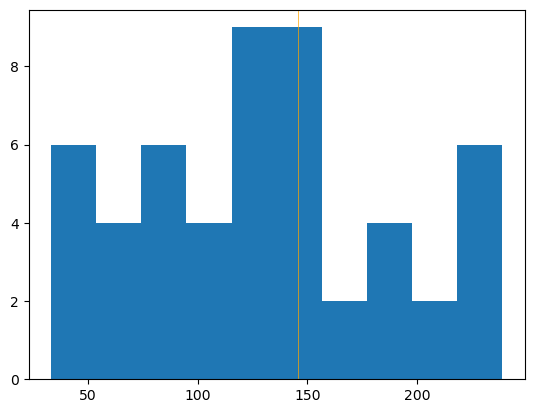

In [13]:
plt.hist(locs)
plt.axvline(puff_location, color='orange', linewidth=0.5, label='Airpuff location')

In [14]:
all_spk_positions = flatten(spk_positions)

NameError: name 'flatten' is not defined

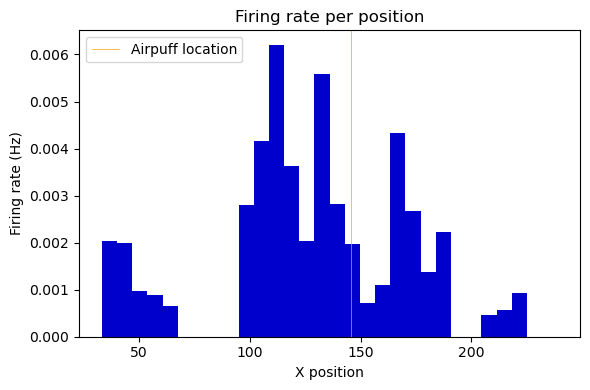

In [15]:

# Create a figure
plt.figure(figsize=(6, 4))

# Loop through each list in spk_positions and plot its histogram
# for i, spk_pos in enumerate(position_firing_rate):
#     plt.hist(spk_pos, bins=20, alpha=0.5, label=f'Neuron {i}')  # Adjust alpha for transparency
#     # plt.axvline(puff_location)
plt.hist(bin_edges[:-1], weights=position_firing_rate, bins=30, color='mediumblue')
plt.axvline(puff_location, color='orange', linewidth=0.5, label='Airpuff location')

# Add labels, title, and legend
plt.xlabel("X position")
plt.ylabel("Firing rate (Hz)")
plt.title("Firing rate per position")
plt.legend(loc='upper left')  # Adjust legend position
# plt.savefig('firingrate_position.png')
# plt.savefig('firingrate_position.svg')

# Show the plot
plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(10, 6))

for i, firing_rate in enumerate(position_firing_rates):
    plt.hist(bin_edges[:-1], bins=bin_edges, weights=firing_rate, alpha=0.5, label=f'Neuron {i+1}', color='b')
plt.axvline(puff_location, color='r')

# Add labels and title
plt.xlabel("Position")
plt.ylabel("Firing Rate")
plt.title("Overlay of Position Firing Rates for All Neurons")
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))

# Show the plot
plt.tight_layout()
plt.show()

/Users/laravlasblom/Documents/Radboud/Thesis/Code/URI-project/data_loader.py:592: UserWarning: The file does not exist in the dataset, check the folder 
 /Users/laravlasblom/Documents/Radboud/Thesis/Code/Data/GG-Dataset-Tulio-Ultralight/Rat11/Rat11-20150402/Rat11-20150402.puf.evt
  self.__warning_msg(path)
/Users/laravlasblom/Documents/Radboud/Thesis/Code/URI-project/data_loader.py:517: UserWarning: The file does not exist in the dataset, check the folder 
 /Users/laravlasblom/Documents/Radboud/Thesis/Code/Data/GG-Dataset-Tulio-Ultralight/Rat11/Rat11-20150318/Rat11-20150318-pos.csv
  self.__warning_msg(self.paths[rat][session]['position'])
/Users/laravlasblom/Documents/Radboud/Thesis/Code/URI-project/data_loader.py:517: UserWarning: The file does not exist in the dataset, check the folder 
 /Users/laravlasblom/Documents/Radboud/Thesis/Code/Data/GG-Dataset-Tulio-Ultralight/Rat11/Rat11-20150315/Rat11-20150315-pos.csv
  self.__warning_msg(self.paths[rat][session]['position'])
/Users/larav

1


/Users/laravlasblom/Documents/Radboud/Thesis/Code/URI-project/data_loader.py:517: UserWarning: The file does not exist in the dataset, check the folder 
 /Users/laravlasblom/Documents/Radboud/Thesis/Code/Data/GG-Dataset-Tulio-Ultralight/Rat10/Rat10-20140704/Rat10-20140704-pos.csv
  self.__warning_msg(self.paths[rat][session]['position'])


1
2


/Users/laravlasblom/Documents/Radboud/Thesis/Code/URI-project/data_loader.py:517: UserWarning: The file does not exist in the dataset, check the folder 
 /Users/laravlasblom/Documents/Radboud/Thesis/Code/Data/GG-Dataset-Tulio-Ultralight/Rat10/Rat10-20140704/Rat10-20140704-pos.csv
  self.__warning_msg(self.paths[rat][session]['position'])


...

3


/Users/laravlasblom/Documents/Radboud/Thesis/Code/URI-project/data_loader.py:517: UserWarning: The file does not exist in the dataset, check the folder 
 /Users/laravlasblom/Documents/Radboud/Thesis/Code/Data/GG-Dataset-Tulio-Ultralight/Rat08/Rat08-20130718/Rat08-20130718-pos.csv
  self.__warning_msg(self.paths[rat][session]['position'])


3
4


/Users/laravlasblom/Documents/Radboud/Thesis/Code/URI-project/data_loader.py:517: UserWarning: The file does not exist in the dataset, check the folder 
 /Users/laravlasblom/Documents/Radboud/Thesis/Code/Data/GG-Dataset-Tulio-Ultralight/Rat08/Rat08-20130718/Rat08-20130718-pos.csv
  self.__warning_msg(self.paths[rat][session]['position'])


4


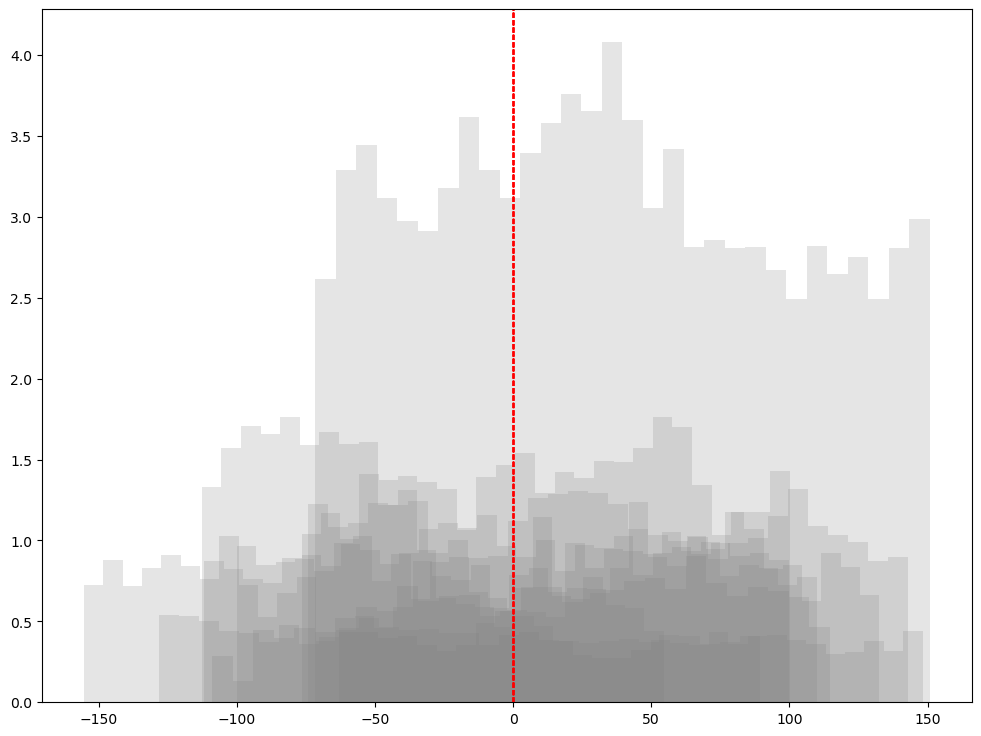

In [68]:
def find_firing_rate_pos(s):
    session, session_neurons, n_neurons, neuron_ids, start_time, end_time, airpuff_times = session_vars(s)
    x, y, time = position_vars(session)
    airpuff_x_positions = np.interp(airpuff_times, time, x)
    puff_location = np.mean(airpuff_x_positions)

    neurons = list(spks[rat][session]['all'].keys())
    spk_times = list(spks[rat][session]['all'].values())

    spk_times = [np.array(x) / 1000 for x in spk_times]  
    idx = [np.round(x * sampling_rate).astype(int) for x in spk_times]
    spk_positions = [x[i] for i in idx]
    all_spk_positions = np.concatenate(spk_positions) 

    x_normalized = x - puff_location
    spk_positions_normalized = all_spk_positions - puff_location

    min_value = min(x_normalized.min(), spk_positions_normalized.min())
    max_value = max(x_normalized.max(), spk_positions_normalized.max())

    num_bins = 30  # Number of bins
    bin_edges = np.linspace(min_value, max_value, num_bins + 1)

    position_occupancy = np.histogram(x_normalized, bins=bin_edges)[0]
    position_spk_count = np.histogram(spk_positions_normalized, bins=bin_edges)[0]

    position_firing_rate = np.divide(
        position_spk_count, position_occupancy, 
        out=np.zeros_like(position_spk_count, dtype=float), where=position_occupancy != 0
    )

    return position_firing_rate, 0, bin_edges  

rat_id = 3
rat = rats[rat_id]
data = load_data(rat)
spks = data.get_spk()
pos = data._get_pos()

valid_sessions = [0, 1, 5, 10, 13]

plt.figure(figsize=(12, 9))
for i, s in enumerate(valid_sessions):
    fr, puff, be = find_firing_rate_pos(s)
    plt.hist(be[:-1], weights=fr, bins=be, alpha=0.2, color='grey', label=f'Session {s}')
    plt.axvline(puff, color='red', linestyle='--', linewidth=1)

# plt.xlabel('Position (Normalized)')
# plt.ylabel('Firing Rate')
# plt.title('Firing Rate per Position Across Sessions (Normalized)')
# plt.legend()
# plt.show()


rat_id = 2
rat = rats[rat_id]
data = load_data(rat)
spks = data.get_spk()
pos = data._get_pos()


valid_sessions = [1, 2, 3]

# plt.figure(figsize=(1, 10))
for i, s in enumerate(valid_sessions):
    print(s)
    fr, puff, be = find_firing_rate_pos(s)
    plt.hist(be[:-1], weights=fr, bins=be, alpha=0.2, color='grey', label=f'Session {s}')
    plt.axvline(puff, color='red', linestyle='--', linewidth=1)
    print(s)

# plt.xlabel('Position (Normalized)')
# plt.ylabel('Firing Rate')
# plt.title('Firing Rate per Position Across Sessions (Normalized)')
# plt.legend()
# plt.show()

rat_id = 0
rat = rats[rat_id]
data = load_data(rat)
spks = data.get_spk()
pos = data._get_pos()


valid_sessions = [3, 4]

# plt.figure(figsize=(10, 6))
for i, s in enumerate(valid_sessions):
    print(s)
    fr, puff, be = find_firing_rate_pos(s)
    plt.hist(be[:-1], weights=fr, bins=be, alpha=0.2, color='grey', label=f'Session {s}')
    plt.axvline(puff, color='red', linestyle='--', linewidth=1)
    print(s)

# plt.xlabel('Position (Normalized)')
# plt.ylabel('Firing Rate')
# plt.title('Firing Rate per Position Across Sessions (Normalized)')
# plt.ylim(0,2)
# plt.legend()
plt.savefig('position_firing_rate_puff.svg')
plt.show()

In [75]:
    min_value = min(x.min(), min(spk_positions[i]))
    max_value = max(x.max(), max(spk_positions[i]))
    
    num_bins = 30  # Number of bins
    bin_edges = np.linspace(min_value, max_value, num_bins + 1)
    
    position_occupancy = np.histogram(x, bins=bin_edges)
    position_spk_count = np.histogram(spk_positions[i], bins=bin_edges)
    
    position_firing_rate = [x / y for x, y in zip(position_spk_count[0], position_occupancy[0])]
    highest_firing_rate.append(max(position_firing_rate))
    n = np.argmax(position_firing_rate)
    locs.append(bin_edges[n])

IndexError: list index out of range

In [113]:
def find_firing_rate_pos(s):
    highest_firing_rate = []
    locs = []

    session, session_neurons, n_neurons, neuron_ids, start_time, end_time, airpuff_times = session_vars(s)
    x, y, time = position_vars(session)
    airpuff_x_positions = np.interp(airpuff_times, time, x)
    puff_location = np.mean(airpuff_x_positions)

    neurons = list(spks[rat][session]['all'].keys())
    spk_times = list(spks[rat][session]['all'].values())

    spk_times = [np.array(x) / 1000 for x in spk_times]  
    idx = [np.round(x * sampling_rate).astype(int) for x in spk_times]
    spk_positions = [x[i] for i in idx]
    print(len(spk_positions))
    # all_spk_positions = np.concatenate(spk_positions) 
    for i in range(len(spk_positions)):
        min_value = min(x.min(), min(spk_positions[i]))
        max_value = max(x.max(), max(spk_positions[i]))
        
        num_bins = 30  # Number of bins
        # bin_edges = np.linspace(min_value, max_value, num_bins + 1)
        
        position_occupancy = np.histogram(x, bins=bin_edges)
        position_spk_count = np.histogram(spk_positions[i], bins=bin_edges)
        
        position_firing_rate = [x / y for x, y in zip(position_spk_count[0], position_occupancy[0])]
        highest_firing_rate.append(max(position_firing_rate))
        n = np.argmax(position_firing_rate)
        locs.append(bin_edges[n])

    return locs, highest_firing_rate 

rat_id = 3
rat = rats[rat_id]
data = load_data(rat)
spks = data.get_spk()
pos = data._get_pos()

valid_sessions = [0, 1, 5, 10, 13]
highest_firing_rate = []
locs = []

plt.figure(figsize=(12, 9))
for i, s in enumerate(valid_sessions):
    h, l = find_firing_rate_pos(s)
    highest_firing_rate.append(h)
    locs.append(l)
    

rat_id = 2
rat = rats[rat_id]
data = load_data(rat)
spks = data.get_spk()
pos = data._get_pos()


valid_sessions = [1, 2, 3]

# plt.figure(figsize=(1, 10))
for i, s in enumerate(valid_sessions):
    h, l = find_firing_rate_pos(s)
    highest_firing_rate.append(h)
    locs.append(l)

# plt.xlabel('Position (Normalized)')
# plt.ylabel('Firing Rate')
# plt.title('Firing Rate per Position Across Sessions (Normalized)')
# plt.legend()
# plt.show()

rat_id = 0
rat = rats[rat_id]
data = load_data(rat)
spks = data.get_spk()
pos = data._get_pos()


valid_sessions = [3, 4]

# plt.figure(figsize=(10, 6))
for i, s in enumerate(valid_sessions):
    h, l = find_firing_rate_pos(s)
    highest_firing_rate.append(h)
    locs.append(l)


# plt.xlabel('Position (Normalized)')
# plt.ylabel('Firing Rate')
# plt.title('Firing Rate per Position Across Sessions (Normalized)')
# plt.ylim(0,2)
# plt.legend()
# plt.savefig('position_firing_rate_puff.svg')


/Users/laravlasblom/Documents/Radboud/Thesis/Code/URI-project/data_loader.py:592: UserWarning: The file does not exist in the dataset, check the folder 
 /Users/laravlasblom/Documents/Radboud/Thesis/Code/Data/GG-Dataset-Tulio-Ultralight/Rat11/Rat11-20150402/Rat11-20150402.puf.evt
  self.__warning_msg(path)
/Users/laravlasblom/Documents/Radboud/Thesis/Code/URI-project/data_loader.py:517: UserWarning: The file does not exist in the dataset, check the folder 
 /Users/laravlasblom/Documents/Radboud/Thesis/Code/Data/GG-Dataset-Tulio-Ultralight/Rat11/Rat11-20150318/Rat11-20150318-pos.csv
  self.__warning_msg(self.paths[rat][session]['position'])
/Users/laravlasblom/Documents/Radboud/Thesis/Code/URI-project/data_loader.py:517: UserWarning: The file does not exist in the dataset, check the folder 
 /Users/laravlasblom/Documents/Radboud/Thesis/Code/Data/GG-Dataset-Tulio-Ultralight/Rat11/Rat11-20150315/Rat11-20150315-pos.csv
  self.__warning_msg(self.paths[rat][session]['position'])
/Users/larav

40


/Users/laravlasblom/Documents/Radboud/Thesis/Code/URI-project/data_loader.py:517: UserWarning: The file does not exist in the dataset, check the folder 
 /Users/laravlasblom/Documents/Radboud/Thesis/Code/Data/GG-Dataset-Tulio-Ultralight/Rat11/Rat11-20150318/Rat11-20150318-pos.csv
  self.__warning_msg(self.paths[rat][session]['position'])
/Users/laravlasblom/Documents/Radboud/Thesis/Code/URI-project/data_loader.py:517: UserWarning: The file does not exist in the dataset, check the folder 
 /Users/laravlasblom/Documents/Radboud/Thesis/Code/Data/GG-Dataset-Tulio-Ultralight/Rat11/Rat11-20150315/Rat11-20150315-pos.csv
  self.__warning_msg(self.paths[rat][session]['position'])
/Users/laravlasblom/Documents/Radboud/Thesis/Code/URI-project/data_loader.py:517: UserWarning: The file does not exist in the dataset, check the folder 
 /Users/laravlasblom/Documents/Radboud/Thesis/Code/Data/GG-Dataset-Tulio-Ultralight/Rat11/Rat11-20150324/Rat11-20150324-pos.csv
  self.__warning_msg(self.paths[rat][se

18


/Users/laravlasblom/Documents/Radboud/Thesis/Code/URI-project/data_loader.py:517: UserWarning: The file does not exist in the dataset, check the folder 
 /Users/laravlasblom/Documents/Radboud/Thesis/Code/Data/GG-Dataset-Tulio-Ultralight/Rat11/Rat11-20150318/Rat11-20150318-pos.csv
  self.__warning_msg(self.paths[rat][session]['position'])
/Users/laravlasblom/Documents/Radboud/Thesis/Code/URI-project/data_loader.py:517: UserWarning: The file does not exist in the dataset, check the folder 
 /Users/laravlasblom/Documents/Radboud/Thesis/Code/Data/GG-Dataset-Tulio-Ultralight/Rat11/Rat11-20150315/Rat11-20150315-pos.csv
  self.__warning_msg(self.paths[rat][session]['position'])
/Users/laravlasblom/Documents/Radboud/Thesis/Code/URI-project/data_loader.py:517: UserWarning: The file does not exist in the dataset, check the folder 
 /Users/laravlasblom/Documents/Radboud/Thesis/Code/Data/GG-Dataset-Tulio-Ultralight/Rat11/Rat11-20150324/Rat11-20150324-pos.csv
  self.__warning_msg(self.paths[rat][se

...

55


/var/folders/ns/_47zlc693097dwsy6flqxvxm0000gn/T/ipykernel_4157/859011993.py:28: RuntimeWarning: invalid value encountered in scalar divide
  position_firing_rate = [x / y for x, y in zip(position_spk_count[0], position_occupancy[0])]
/Users/laravlasblom/Documents/Radboud/Thesis/Code/URI-project/data_loader.py:517: UserWarning: The file does not exist in the dataset, check the folder 
 /Users/laravlasblom/Documents/Radboud/Thesis/Code/Data/GG-Dataset-Tulio-Ultralight/Rat08/Rat08-20130718/Rat08-20130718-pos.csv
  self.__warning_msg(self.paths[rat][session]['position'])


19


/var/folders/ns/_47zlc693097dwsy6flqxvxm0000gn/T/ipykernel_4157/859011993.py:28: RuntimeWarning: invalid value encountered in scalar divide
  position_firing_rate = [x / y for x, y in zip(position_spk_count[0], position_occupancy[0])]


<Figure size 1200x900 with 0 Axes>

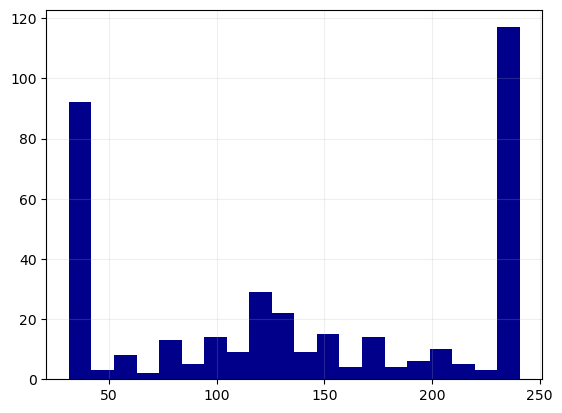

In [112]:
plt.hist(flatten(highest_firing_rate), bins=20, color='darkblue')
plt.grid(True, alpha=0.2)
plt.savefig('highest_firing_rate.svg')